In [5]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [6]:
# Data Preparation

df = pd.read_csv(io.BytesIO(uploaded['q3_retail_promotions.csv']))

In [7]:
# Date Feature Engineering

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)
df

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024-12-28,39,large,urban,bogo,1,0,3,384,2024,12,5,1
1196,2024-12-28,44,medium,urban,category_offer,1,0,9,371,2024,12,5,1
1197,2024-12-29,47,large,semi-urban,bogo,1,0,7,367,2024,12,6,1
1198,2024-12-31,25,small,urban,bogo,0,0,6,321,2024,12,1,1


In [8]:
# Temporal Train-Test Split

df = df.sort_values(by='transaction_date')

# Split index for train and test

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# Train and test sets

X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

Train set shape: (960, 13)
Test set shape: (240, 13)


A random split mixes past and future data. This causes data leakage, because the model learns from future events and is tested on earlier ones, making results look better than they really are.

In real use, a model predicts future data from past data. So the test set should come after the training set in time. A temporal split does this, giving a more realistic performance estimate and capturing patterns like seasonality or trends that a random split might hide.

In [9]:
print(X_train.head())

   store_id store_size location_type  promotion_type  is_weekend  is_festival  \
0        28      small    semi-urban       free_gift           1            0   
1         5     medium    semi-urban       free_gift           1            1   
2        13      small    semi-urban  loyalty_points           1            0   
3        17      small         urban       free_gift           1            0   
4        50     medium    semi-urban            bogo           0            0   

   competition_density  year  month  day_of_week  is_month_end  
0                    5  2022      1            5             0  
1                    1  2022      1            5             0  
2                    6  2022      1            6             0  
3                    7  2022      1            6             0  
4                    3  2022      1            0             0  


In [10]:
# Preprocessing Pipeline

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

# Numerical and categorical features
numerical_features = ['store_id','is_weekend','is_festival','competition_density','year','month','day_of_week','is_month_end']
categorical_features = ['store_size', 'promotion_type', 'location_type']

# Preprocessing pipeline
prprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [11]:
# Model Training and Evaluation

# Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', prprocessing_pipeline),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [12]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', prprocessing_pipeline),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("Linear Regression - RMSE:", rmse_lr)
print("Linear Regression - MAE:", mae_lr)

# Random Forest Regressor Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("\nRandom Forest Regressor - RMSE:", rmse_rf)
print("Random Forest Regressor - MAE:", mae_rf)

Linear Regression - RMSE: 27.12145116489062
Linear Regression - MAE: 21.052926674588395

Random Forest Regressor - RMSE: 30.742675807960072
Random Forest Regressor - MAE: 24.237250000000003


Based on the results above, the Linear Regression model outperforms the Random Forest model because it achieves lower RMSE and MAE scores. This suggests that Linear Regression captures the underlying pattern more effectively.

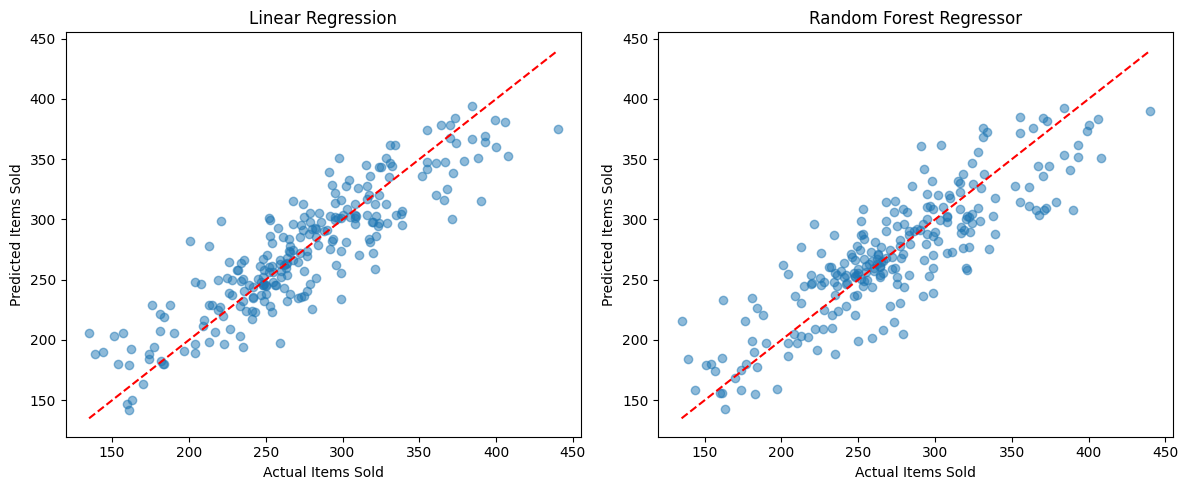

In [16]:
# Making Parity Plots

import matplotlib.pyplot as plt

# Parity plot for Linear Regression
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal reference line
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression')

# Parity plot for Random Forest Regressor
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal reference line
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest Regressor')
plt.tight_layout()
plt.show()

From both graphs, the predicted values lie close to the actual values along the diagonal reference line. However, the Linear Regression plot aligns slightly better, indicating it is the stronger model of the two

In [17]:
# Extracting feature importances from the Random Forest model

rf_model = rf_pipeline.named_steps['regressor']
encoded_feature_names = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_feature_names)
feature_importances = rf_model.feature_importances_
feature_names = all_feature_names

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values('importance', ascending=False)

# Display the top 5 most influential features
print("Top 5 Most Influential Features:")
print(importance_df.head(5))

Top 5 Most Influential Features:
                feature  importance
2           is_festival    0.173414
10     store_size_small    0.166962
18  location_type_urban    0.108373
6           day_of_week    0.083655
1            is_weekend    0.063502


**The sales volume primarily depends on the following features:**
* Events (festivals) are the biggest driver
* Store characteristics (size + location) matter a lot
* Time factors (day of the week/weekend) matter, but less than business context

